<a href="https://colab.research.google.com/github/ekomissarov/demos/blob/main/some_ab_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

$X_1, \ldots, X_n$ — sample from an unknown distribution $P$, $P \in \{P_\theta \mid \theta \in \Theta\}$  
$\hookrightarrow$ i.i.d. r.v.

## Statistics and Estimators

<u>Def.</u> **Statistic** $S(X)$ — a function of the sample.  
<u>Def.</u> **Estimator** $\hat{\theta}(X)$ — a statistic with values in $\Theta$.

<u>Examples:</u>
1) $\overline{g(X_i)} = \frac{1}{n} \sum_{i=1}^n g(X_i) \quad ; \quad \bar{X} = \frac{1}{n} \sum_{i=1}^n X_i$
2) $S_n^2 = \overline{X^2} - \bar{X}^2 = \frac{1}{n} \sum_{i=1}^n (X_i - \bar{X})^2$ (biased)  
   $S^2 = \frac{1}{n-1} \sum_{i=1}^n (X_i - \bar{X})^2$ (unbiased)
3) $X_{(1)}, \ldots, X_{(n)}$ — order statistics (ordered sample), where $X_{(k)}$ is the $k$-th order statistic.

## Properties of Estimators

<u>Def.</u> $\hat{\theta}$ is called **unbiased** if $\mathbb{E}_\theta \hat{\theta} = \theta \quad \forall \theta \in \Theta$  
<u>Example.</u> $\bar{X}$ is an unbiased estimator of $\mathbb{E}_\theta X_1$.

<u>Def.</u> $\hat{\theta}_n = \hat{\theta}(X_1, \ldots, X_n)$ is called a **consistent** estimator of $\theta$ if  
$\hat{\theta}_n \xrightarrow{P_\theta} \theta \quad \forall \theta \in \Theta$, i.e.  
$\forall \theta \in \Theta \quad \forall \varepsilon > 0 \quad \mathbb{P}_\theta(|\hat{\theta}_n - \theta| > \varepsilon) \xrightarrow[n \to \infty]{} 0$.

<u>Def.</u> $\hat{\theta}_n$ is called **strongly consistent** if $\hat{\theta}_n \xrightarrow{\text{a.s.}} \theta \quad \forall \theta \in \Theta$  
$\iff \forall \theta \in \Theta : \mathbb{P}_\theta \left(\hat{\theta}_n \xrightarrow[n \to \infty]{} \theta\right) = 1$.

<u>Def.</u> $\hat{\theta}_n$ is an **asymptotically normal** estimator of $\theta$ if  
$$\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2(\theta)) \quad \text{as } n \to \infty$$  
$\hookrightarrow \sigma^2(\theta)$ is the asymptotic variance.

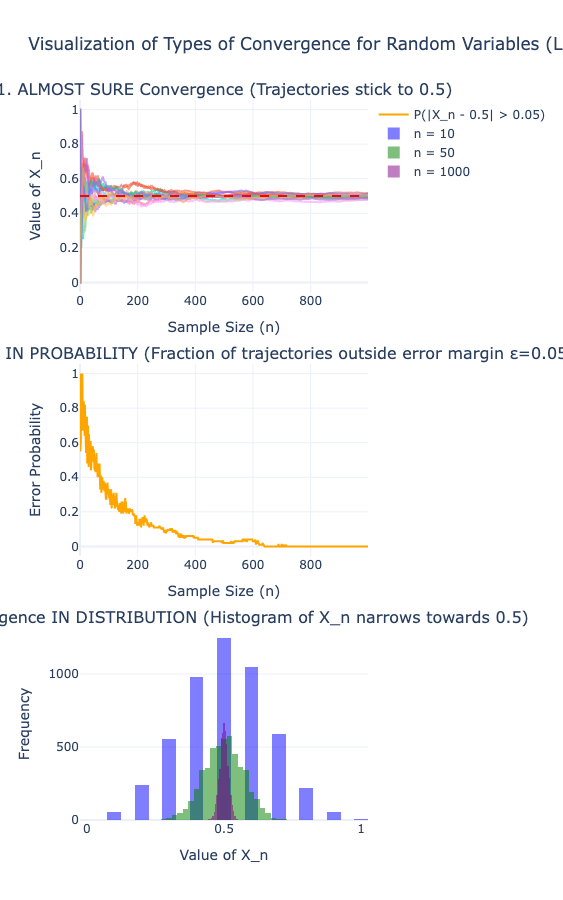

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set random seed for reproducibility
np.random.seed(42)

# -----------------------------------------------------------------------------
# 1. SIMULATE DATA (Coin flips: 0 or 1, true mean = 0.5)
# -----------------------------------------------------------------------------
num_trajectories = 100  # Number of individual simulations (for a.s. and in probability)
n_steps = 1000          # Number of steps (sample size n)

# Generate flips: array of shape (num_trajectories, n_steps)
draws = np.random.binomial(n=1, p=0.5, size=(num_trajectories, n_steps))

# Cumulative sample mean X_n for each trajectory
X_n = np.cumsum(draws, axis=1) / np.arange(1, n_steps + 1)

# -----------------------------------------------------------------------------
# 2. CREATE INTERACTIVE PLOTS (Plotly)
# -----------------------------------------------------------------------------
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        "1. ALMOST SURE Convergence (Trajectories stick to 0.5)",
        "2. Convergence IN PROBABILITY (Fraction of trajectories outside error margin ε=0.05)",
        "3. Convergence IN DISTRIBUTION (Histogram of X_n narrows towards 0.5)"
    ),
    vertical_spacing=0.1
)

# --- Plot 1: Almost sure convergence ---
for i in range(min(15, num_trajectories)):  # show 15 random trajectories
    fig.add_trace(
        go.Scatter(y=X_n[i], mode='lines', opacity=0.6, showlegend=False),
        row=1, col=1
    )
fig.add_hline(y=0.5, line_dash="dash", line_color="red", row=1, col=1)

# --- Plot 2: Convergence in probability ---
epsilon = 0.05
# Fraction of trajectories exceeding boundaries [0.5 - eps, 0.5 + eps] at each step n
out_of_bounds_prob = np.mean(np.abs(X_n - 0.5) > epsilon, axis=0)

fig.add_trace(
    go.Scatter(y=out_of_bounds_prob, mode='lines', name=f'P(|X_n - 0.5| > {epsilon})', line=dict(color='orange')),
    row=2, col=1
)

# --- Plot 3: Convergence in distribution ---
# Compare distribution of X_n at n=10, n=50, and n=1000 across 5000 simulations
draws_large = np.random.binomial(n=1, p=0.5, size=(5000, n_steps))
X_n_large = np.cumsum(draws_large, axis=1) / np.arange(1, n_steps + 1)

for n_val, color in zip([10, 50, 1000], ['blue', 'green', 'purple']):
    fig.add_trace(
        go.Histogram(
            x=X_n_large[:, n_val - 1],
            name=f'n = {n_val}',
            opacity=0.5,
            nbinsx=30,
            marker_color=color
        ),
        row=3, col=1
    )

# -----------------------------------------------------------------------------
# 3. LAYOUT AND STYLING
# -----------------------------------------------------------------------------
fig.update_xaxes(title_text="Sample Size (n)", row=1, col=1)
fig.update_yaxes(title_text="Value of X_n", row=1, col=1)

fig.update_xaxes(title_text="Sample Size (n)", row=2, col=1)
fig.update_yaxes(title_text="Error Probability", row=2, col=1)

fig.update_xaxes(title_text="Value of X_n", row=3, col=1)
fig.update_yaxes(title_text="Frequency", row=3, col=1)

fig.update_layout(
    height=900,
    title_text="Visualization of Types of Convergence for Random Variables (LLN)",
    barmode='overlay',
    template='plotly_white'
)

fig.show()

<u>Def.</u> **Asymptotically Normal Estimator (ANE):**  
$$\sqrt{n}(\hat{\theta} - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2(\theta))$$  
$$\hat{\theta} \sim \mathcal{N}\left(\theta, \frac{\sigma^2(\theta)}{n}\right)$$

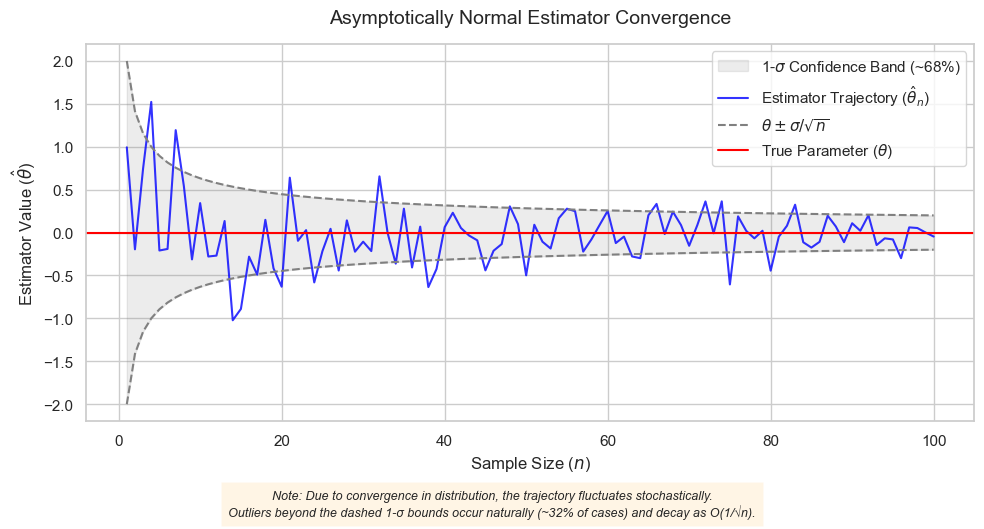

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# -----------------------------------------------------------------------------
# 1. DATA GENERATION
# -----------------------------------------------------------------------------
np.random.seed(42)
n = np.arange(1, 101)
theta = 0  # True parameter value
sigma = 2.0  # Asymptotic standard deviation

# Simulate a stochastic trajectory with decaying variance ~ sigma^2 / n
noise = np.random.normal(0, 1, size=len(n))
fluctuations = theta + (sigma / np.sqrt(n)) * noise

# Theoretical 1-sigma standard error bounds (~68% coverage)
upper_bound = theta + sigma / np.sqrt(n)
lower_bound = theta - sigma / np.sqrt(n)

# -----------------------------------------------------------------------------
# 2. PLOTTING (Matplotlib & Seaborn)
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded area representing the +-1 std error band
ax.fill_between(n, lower_bound, upper_bound, color='gray', alpha=0.15, label=r'1-$\sigma$ Confidence Band (~68%)')

# Plot the trajectory of estimator \hat{\theta}
ax.plot(n, fluctuations, color='blue', linewidth=1.5, alpha=0.8, label=r'Estimator Trajectory ($\hat{\theta}_n$)')

# Plot the standard error bounds
ax.plot(n, upper_bound, color='gray', linestyle='--', label=r'$\theta \pm \sigma / \sqrt{n}$')
ax.plot(n, lower_bound, color='gray', linestyle='--')

# Plot the true parameter value \theta
ax.axhline(y=theta, color='red', linewidth=1.5, linestyle='-', label=r'True Parameter ($\theta$)')

# -----------------------------------------------------------------------------
# 3. LAYOUT AND CAPTION
# -----------------------------------------------------------------------------
ax.set_title("Asymptotically Normal Estimator Convergence", fontsize=14, pad=15)
ax.set_xlabel("Sample Size ($n$)", fontsize=12)
ax.set_ylabel(r"Estimator Value ($\hat{\theta}$)", fontsize=12)

# Explanatory caption using correct matplotlib parameters (style='italic')
caption_text = (
    "Note: Due to convergence in distribution, the trajectory fluctuates stochastically.\n"
    "Outliers beyond the dashed 1-σ bounds occur naturally (~32% of cases) and decay as O(1/√n)."
)
plt.figtext(
    0.5, -0.05, caption_text,
    ha="center", fontsize=9, style="italic",
    bbox={"facecolor": "orange", "alpha": 0.1, "pad": 5}
)

ax.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.show()

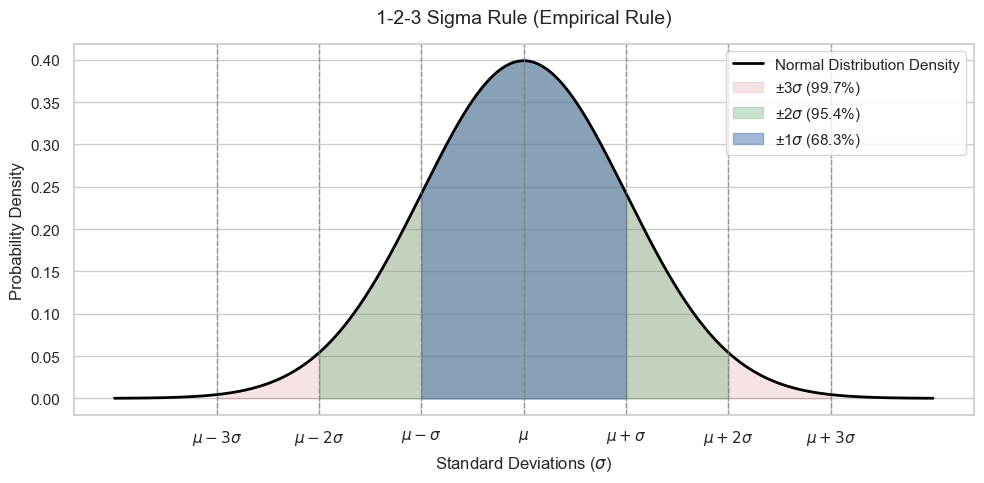

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set style
sns.set_theme(style="whitegrid")

# -----------------------------------------------------------------------------
# 1. DATA PREPARATION
# -----------------------------------------------------------------------------
mu = 0       # Mean
sigma = 1    # Standard deviation

# Generate x values around the mean
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Sigma intervals and corresponding coverage percentages
sigmas = [
    (1, "68.3%", "#4C72B0", 0.50),  # 1-sigma (Blue)
    (2, "95.4%", "#55A868", 0.30),  # 2-sigma (Green)
    (3, "99.7%", "#C44E52", 0.15)   # 3-sigma (Red)
]

# -----------------------------------------------------------------------------
# 2. PLOTTING
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the normal distribution density curve
ax.plot(x, y, color="black", linewidth=2, label="Normal Distribution Density")

# Fill regions for 3, 2, and 1 sigma (drawn in reverse order for layering)
for num_sigma, label, color, alpha in reversed(sigmas):
    x_fill = np.linspace(mu - num_sigma * sigma, mu + num_sigma * sigma, 500)
    y_fill = norm.pdf(x_fill, mu, sigma)
    ax.fill_between(
        x_fill, y_fill,
        color=color, alpha=alpha,
        label=rf"±{num_sigma}$\sigma$ ({label})"
    )

# Vertical lines for mean and sigma steps
for i in range(-3, 4):
    ax.axvline(
        x=mu + i * sigma,
        color="gray", linestyle="--",
        linewidth=1, alpha=0.7
    )

# -----------------------------------------------------------------------------
# 3. LAYOUT AND ANNOTATIONS
# -----------------------------------------------------------------------------
ax.set_title("1-2-3 Sigma Rule (Empirical Rule)", fontsize=14, pad=15)
ax.set_xlabel(r"Standard Deviations ($\sigma$)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)

# Custom x-axis ticks with sigma notation
ax.set_xticks([mu + i * sigma for i in range(-3, 4)])
ax.set_xticklabels([r"$\mu-3\sigma$", r"$\mu-2\sigma$", r"$\mu-\sigma$",
                    r"$\mu$",
                    r"$\mu+\sigma$", r"$\mu+2\sigma$", r"$\mu+3\sigma$"])

ax.legend(loc="upper right", frameon=True)
plt.tight_layout()

plt.show()

## <u>How to obtain such properties of estimators?</u>

<u>Theorem (SLLN)</u> Let $X_1, \ldots, X_n, \ldots$ be i.i.d. r.v. with finite $\mathbb{E}X_1$, then  
$$\frac{X_1 + \ldots + X_n}{n} \xrightarrow{\text{a.s.}} \mathbb{E}X_1$$

<u>Theorem (CLT)</u> Let $X_1, \ldots, X_n, \ldots$ be i.i.d. r.v. with finite covariance matrix $\Sigma$, then  
$$\sqrt{n} \left( \frac{1}{n} \sum_{i=1}^n X_i - \mathbb{E}X_1 \right) \xrightarrow{d} \mathcal{N}(0, \Sigma)$$  
$\bar{X}$ is an ANE of $\mathbb{E}X_1$ with asymptotic covariance matrix $\Sigma$

<u>Example (*).</u> Let $X_1, \ldots, X_n \sim \operatorname{Exp}(\theta), \quad p_\theta(x) = \theta e^{-\theta x}$

$\Delta \quad \mathbb{E}_\theta X_1 = \frac{1}{\theta}, \quad \mathbb{D}_\theta X_1 = \frac{1}{\theta^2}$  
$\text{CLT: } \sqrt{n} \left( \bar{X} - \frac{1}{\theta} \right) \xrightarrow{d} \mathcal{N}\left(0, \frac{1}{\theta^2}\right) \Rightarrow \bar{X} \text{ is an ANE of } \frac{1}{\theta} \text{ with asymptotic variance } \frac{1}{\theta^2} \quad \square$

---

<u>Example.</u> $X_1, \ldots, X_n \sim U[0, \theta]$. Find a consistent estimator of $\theta$.

$\Delta \quad$ Let us take $X_{(n)}$  
$$\mathbb{P}_\theta (|X_{(n)} - \theta| > \varepsilon) = \mathbb{P}_\theta (X_{(n)} < \theta - \varepsilon) = \mathbb{P} \left( \bigcap_{i=1}^n \{X_i < \theta - \varepsilon\} \right)$$  
$$= \prod_{i=1}^n \mathbb{P}(X_i < \theta - \varepsilon) = \left( \frac{\theta - \varepsilon}{\theta} \right)^n = \left( 1 - \frac{\varepsilon}{\theta} \right)^n \xrightarrow[n \to \infty]{} 0$$  
$\Rightarrow X_{(n)}$ is a consistent estimator of $\theta \quad \square$

## Unbiasedness of Estimators

Let $X_1, \ldots, X_n$ be a sample from the distribution $\mathcal{N}(0, \sigma^2)$. It is known that $S^2$ and $\frac{n}{n-1} S^2$ can be used as estimators for the parameter $\sigma^2$.

**Reminder:** $S^2 := \frac{1}{n} \sum_{i=1}^n (X_i - \bar{X})^2 = \overline{X^2} - \bar{X}^2$

**Question:** Which of these estimators are unbiased?

---

**Answer:** $\frac{n}{n-1} S^2$.

$$\mathbb{E}_\sigma S^2 = \mathbb{E}_\sigma \overline{X^2} - \mathbb{E}_\sigma \bar{X}^2 = \frac{1}{n} \mathbb{E}_\sigma \sum_{i=1}^n X_i^2 - \frac{1}{n^2} \mathbb{E}_\sigma \sum_{i=1}^n X_i^2 - \frac{1}{n^2} \sum_{i \neq j} \mathbb{E}_\sigma X_i X_j = \frac{n-1}{n} \mathbb{E}_\sigma X^2 - \frac{n(n-1)}{n^2} \mathbb{E}_\sigma X^2 = \frac{n-1}{n} \mathbb{D}_\sigma X$$

$\Rightarrow S^2$ is a biased estimator, while $\frac{n}{n-1} S^2$ is an unbiased estimator of $\sigma^2$, also known as the adjusted (or corrected) sample variance.


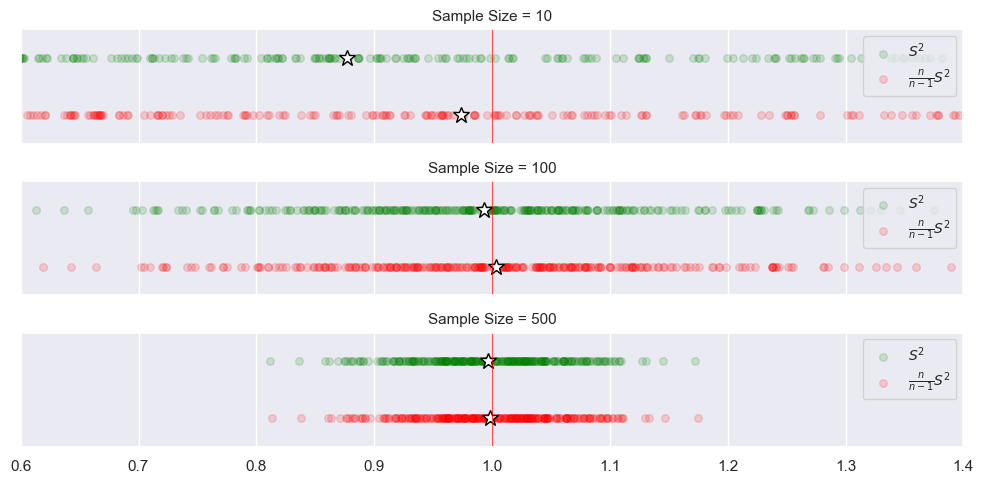

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# -----------------------------------------------------------------------------
# 1. GENERATE DATA
# -----------------------------------------------------------------------------
np.random.seed(42)
num_experiments = 300  # Number of simulated samples per plot
sample_sizes = [10, 100, 500]
true_variance = 1.0

# -----------------------------------------------------------------------------
# 2. PLOTTING
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(len(sample_sizes), 1, figsize=(10, 5), sharex=True)

for i, n in enumerate(sample_sizes):
    ax = axes[i]

    # Generate samples from N(0, 1) of shape (num_experiments, n)
    samples = np.random.normal(loc=0, scale=np.sqrt(true_variance), size=(num_experiments, n))

    # Calculate S^2 (biased, ddof=0) and n/(n-1)*S^2 (unbiased, ddof=1)
    s2_biased = np.var(samples, axis=-1, ddof=0)
    s2_unbiased = np.var(samples, axis=-1, ddof=1)

    # Calculate empirical means of the estimators
    mean_biased = np.mean(s2_biased)
    mean_unbiased = np.mean(s2_unbiased)

    # Scatter points along two horizontal lines (y=1 for S^2, y=0 for adjusted S^2)
    ax.scatter(s2_biased, np.ones(num_experiments) * 1, color='green', alpha=0.15, s=30, label=r'$S^2$')
    ax.scatter(s2_unbiased, np.zeros(num_experiments) * 1, color='red', alpha=0.15, s=30, label=r'$\frac{n}{n-1}S^2$')

    # Plot stars for the average value across simulations
    ax.plot(mean_biased, 1, marker='*', markersize=12, color='white', markeredgecolor='black')
    ax.plot(mean_unbiased, 0, marker='*', markersize=12, color='white', markeredgecolor='black')

    # Vertical line at the true variance value (1.0)
    ax.axvline(x=true_variance, color='red', linestyle='-', linewidth=0.8, alpha=0.7)

    # Subplot formatting
    ax.set_title(f"Sample Size = {n}", fontsize=11)
    ax.set_ylim(-0.5, 1.5)
    ax.set_yticks([])  # Hide y-axis ticks
    ax.set_xlim(0.6, 1.4)

    # Custom legend matching the image style
    ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

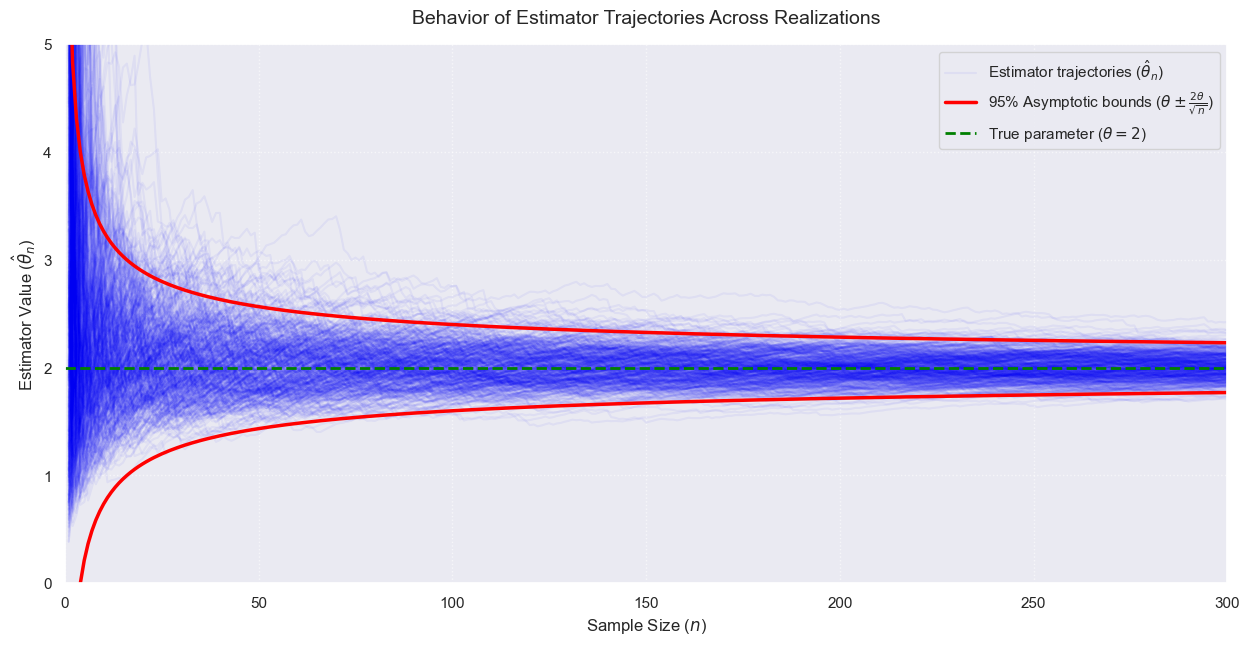

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

# Set seed for reproducibility
np.random.seed(42)

# -----------------------------------------------------------------------------
# 1. SIMULATION
# -----------------------------------------------------------------------------
theta = 2  # True parameter value
size = 300  # Sample size
samples_count = 500  # Number of samples
n_range = np.arange(size) + 1  # Subsample sizes

# Generate multiple samples from Exp(theta) with scale = 1/theta
samples = sps.expon(scale=1/theta).rvs(size=(samples_count, size))

# Compute estimations depending on sample size n
# estimation = n / sum(X_i) -> MLE for parameter theta
estimation = n_range / samples.cumsum(axis=1)

# -----------------------------------------------------------------------------
# 2. PLOTTING
# -----------------------------------------------------------------------------
plt.figure(figsize=(15, 7))

# Plot estimation trajectories for each sample
for i in range(samples_count):
    # Only assign label to the first trajectory to avoid duplicate legend entries
    label = r'Estimator trajectories ($\hat{\theta}_n$)' if i == 0 else None
    plt.plot(n_range, estimation[i], color='blue', alpha=0.05, label=label)

# Asymptotic 95% confidence bounds: theta +/- 2 * theta / sqrt(n)
upper_bound = theta + 2 * theta / np.sqrt(n_range)
lower_bound = theta - 2 * theta / np.sqrt(n_range)

plt.plot(n_range, upper_bound, color='red', lw=2.5, label=r'95% Asymptotic bounds ($\theta \pm \frac{2\theta}{\sqrt{n}}$)')
plt.plot(n_range, lower_bound, color='red', lw=2.5)

# Plot true parameter theta line
plt.axhline(y=theta, color='green', linestyle='--', linewidth=2, label=r'True parameter ($\theta = 2$)')

# Subplot formatting and labels
plt.title('Behavior of Estimator Trajectories Across Realizations', fontsize=14, pad=15)
plt.xlabel('Sample Size ($n$)', fontsize=12)
plt.ylabel(r'Estimator Value ($\hat{\theta}_n$)', fontsize=12)

plt.ylim((0, 5))
plt.xlim((0, size))

plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

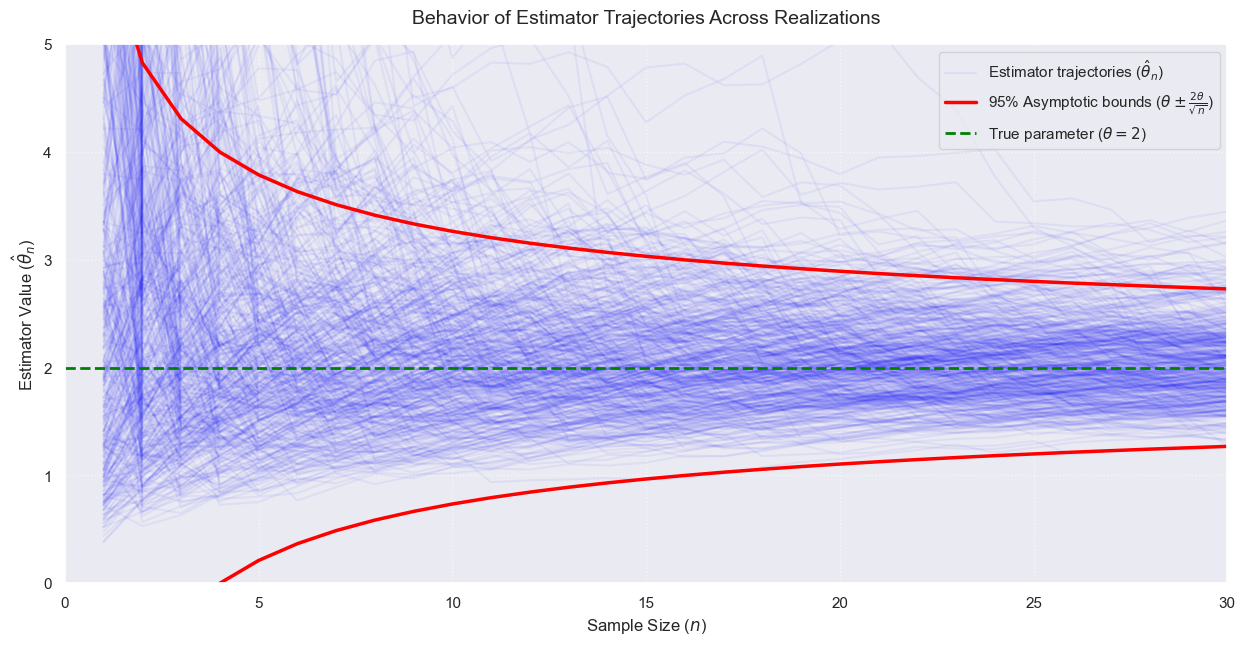

In [ ]:
plt.figure(figsize=(15, 7))

# Plot estimation trajectories for each sample
for i in range(samples_count):
    # Only assign label to the first trajectory to avoid duplicate legend entries
    label = r'Estimator trajectories ($\hat{\theta}_n$)' if i == 0 else None
    plt.plot(n_range, estimation[i], color='blue', alpha=0.05, label=label)

# Asymptotic 95% confidence bounds: theta +/- 2 * theta / sqrt(n)
upper_bound = theta + 2 * theta / np.sqrt(n_range)
lower_bound = theta - 2 * theta / np.sqrt(n_range)

plt.plot(n_range, upper_bound, color='red', lw=2.5, label=r'95% Asymptotic bounds ($\theta \pm \frac{2\theta}{\sqrt{n}}$)')
plt.plot(n_range, lower_bound, color='red', lw=2.5)

# Plot true parameter theta line
plt.axhline(y=theta, color='green', linestyle='--', linewidth=2, label=r'True parameter ($\theta = 2$)')

# Subplot formatting and labels
plt.title('Behavior of Estimator Trajectories Across Realizations', fontsize=14, pad=15)
plt.xlabel('Sample Size ($n$)', fontsize=12)
plt.ylabel(r'Estimator Value ($\hat{\theta}_n$)', fontsize=12)

plt.ylim((0, 5))
plt.xlim((0, 30))

plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## <u>Continuous Mapping and Inheritance Theorems</u>

**Theorem.**
1) ANE $\Rightarrow$ consistent estimator (this implication follows from Slutsky's Lemma)  
   strongly consistent $\Rightarrow$ consistent estimator (since a.s. convergence implies convergence in probability)

2) Let $\hat{\theta}_n$ be a (strongly) consistent estimator of $\theta \in \mathbb{R}^d$,  
   $\tau: \mathbb{R}^d \to \mathbb{R}^k$ be continuous on $\Theta$  
   $\Rightarrow \tau(\hat{\theta}_n)$ is a (strongly) consistent estimator of $\tau(\theta)$.

3) **(Delta Method)**  
A way to obtain one ANE from another ANE.  
Let $\hat{\theta}_n$ be an ANE of $\theta \in \mathbb{R}^d$ with asymptotic covariance matrix $\Sigma(\theta)$,  
   $\tau: \mathbb{R}^d \to \mathbb{R}^k$ be continuously differentiable on $\Theta$.  
   $\Rightarrow \tau(\hat{\theta}_n)$ is an ANE of $\tau(\theta)$ with asymptotic covariance matrix $D(\theta) \Sigma(\theta) D(\theta)^\top$,  
   where $D(\theta) = \left. \frac{\partial \tau}{\partial \theta} \right|_\theta$.

---

<u>Example (*).</u> $X_1, \ldots, X_n \sim \operatorname{Exp}(\theta) \Rightarrow \bar{X}$ is an ANE of $\frac{1}{\theta}$ with asymptotic variance $\frac{1}{\theta^2}$

$\tau(x) = \frac{1}{x} \Rightarrow$ by the Delta Method, $\frac{1}{\bar{X}}$ is an ANE of $\tau\left(\frac{1}{\theta}\right) = \theta$ with asymptotic variance $\theta^2$  
$\tau'(x) = -\frac{1}{x^2} \Rightarrow D(\theta) = \left. \left(-\frac{1}{x^2}\right) \right|_{\frac{1}{\theta}} = -\theta^2 \Rightarrow D(\theta) \Sigma(\theta) D(\theta)^\top = \frac{1}{\theta^2} \cdot (-\theta^2)^2 = \theta^2$  
$\Rightarrow \frac{1}{\bar{X}}$ is an ANE of $\theta$ with asymptotic variance $\theta^2$

## <u>Methods of Obtaining Estimators</u>
* LLN, CLT
* Method of Moments
* Maximum Likelihood Method
* Sample Quantile Method
* Plug-in Method (Substitution Method)

<u>Plug-in Method</u>

Let $X_1, \ldots, X_n$ be a sample from an unknown distribution $P$.

$\hat{P}_n$ — uniform distribution on the sample elements (empirical distribution).

$$\hat{P}_n(B) = \frac{1}{n} \sum_{i=1}^n \mathbb{I}\{X_i \in B\}; \quad \hat{F}_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbb{I}\{X_i < x\}$$

Let $\theta = \underbrace{G(P)}_{\text{functional}}$. Then $\hat{\theta} = G(\hat{P})$ is the plug-in estimator.

---

<u>Example.</u>  
Let $\theta = \mathbb{E} X_1^2 \ln X_1$. Find the plug-in estimator.

$\Delta \quad \theta = G(P) = \int\limits_{\mathbb{R}} x^2 \ln x \, dF(x) \Rightarrow \hat{\theta} = G(\hat{P}) = \int\limits_{\mathbb{R}} x^2 \ln x \, d\hat{F}_n(x) =$

$$= \underbrace{\frac{1}{n}}_{\substack{\text{prob. of} \\ \text{1 element}}} \sum_{i=1}^n X_i^2 \ln X_i = \overline{X^2 \ln X} \quad \square$$

## <u>Interval Estimation</u>

Dam: 51 ft. Historical data shows deviation from truth is $\pm 9$ ft.  
Predict: 49 ft.

Let $X_1, \ldots, X_n$ be a sample from distribution $P \in \{P_\theta \mid \theta \in \Theta\}$.  
Then a confidence interval of confidence level $\alpha$ is a pair of statistics $(T_1(X), T_2(X))$

if $\forall \theta \in \Theta: \mathbb{P}_\theta (T_1(X) \leqslant \theta \leqslant T_2(X)) \geqslant \alpha \quad (\text{usually } \alpha = 0.95)$.

---

<u>Problem.</u> Let $X_1, \ldots, X_n$ be a sample from a shifted exponential distribution with parameter $\theta$, $p_\theta(x) = e^{-(x - \theta)} \mathbb{I}\{x \geqslant \theta\}$.  
Construct a confidence interval for $\theta$.

$\Delta \quad X_1 - \theta \sim \operatorname{Exp}(1)$  
$$\sum X_i - n\theta \sim \Gamma(1, n)$$ - as a sum of exponential distributions

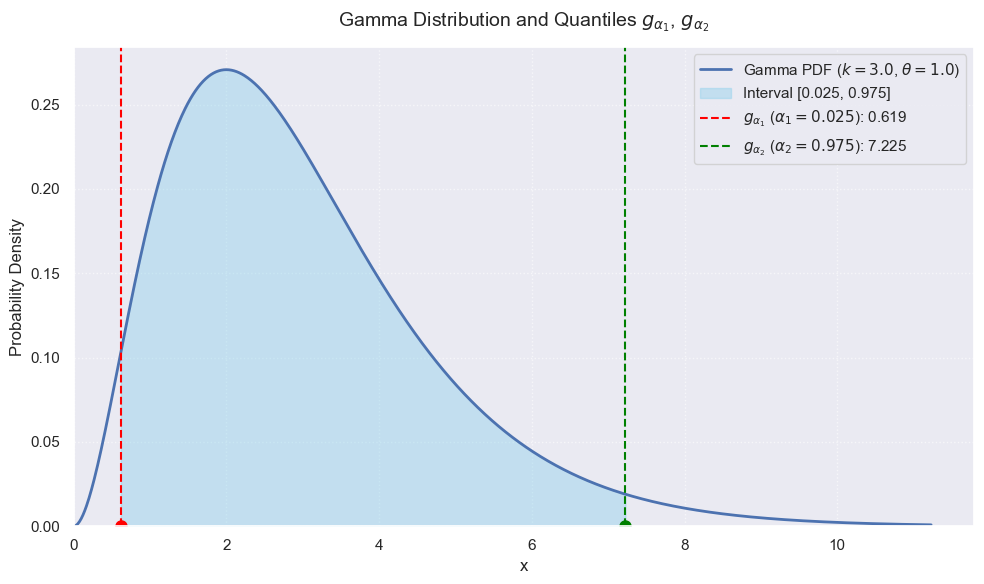

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# -----------------------------------------------------------------------------
# 1. DISTRIBUTION AND QUANTILE PARAMETERS
# -----------------------------------------------------------------------------
# Gamma distribution parameters: shape (k / α) and scale (θ = 1/λ)
shape = 3.0   # Shape parameter
scale = 1.0   # Scale parameter

# Quantile levels
alpha_1 = 0.025
alpha_2 = 0.975

# Compute quantile values using Percent Point Function (PPF)
g_alpha_1 = gamma.ppf(alpha_1, a=shape, scale=scale)
g_alpha_2 = gamma.ppf(alpha_2, a=shape, scale=scale)

# -----------------------------------------------------------------------------
# 2. PLOTTING
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Generate grid of x values
x = np.linspace(0, gamma.ppf(0.999, a=shape, scale=scale), 1000)
y = gamma.pdf(x, a=shape, scale=scale)

# Plot probability density function (PDF)
ax.plot(x, y, 'b-', lw=2, label=rf'Gamma PDF ($k={shape}$, $\theta={scale}$)')

# Fill area between quantiles
x_fill = np.linspace(g_alpha_1, g_alpha_2, 500)
y_fill = gamma.pdf(x_fill, a=shape, scale=scale)
ax.fill_between(x_fill, y_fill, color='skyblue', alpha=0.4, label=f'Interval [{alpha_1}, {alpha_2}]')

# Vertical dashed lines for quantiles
ax.axvline(g_alpha_1, color='red', linestyle='--', lw=1.5,
           label=rf'$g_{{\alpha_1}}$ ($\alpha_1={alpha_1}$): {g_alpha_1:.3f}')
ax.axvline(g_alpha_2, color='green', linestyle='--', lw=1.5,
           label=rf'$g_{{\alpha_2}}$ ($\alpha_2={alpha_2}$): {g_alpha_2:.3f}')

# Highlight quantile markers on the X-axis
ax.plot(g_alpha_1, 0, marker='o', color='red', markersize=8)
ax.plot(g_alpha_2, 0, marker='o', color='green', markersize=8)

# -----------------------------------------------------------------------------
# 3. FORMATTING AND LABELS
# -----------------------------------------------------------------------------
ax.set_title('Gamma Distribution and Quantiles $g_{\\alpha_1}$, $g_{\\alpha_2}$', fontsize=14, pad=15)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

$\Delta \quad X_1 - \theta \sim \operatorname{Exp}(1)$  
$\sum X_i - n\theta \sim \Gamma(n, 1) \Rightarrow$ distribution is known

Choose $\alpha_1, \alpha_2$ such that $\alpha_2 - \alpha_1 = \alpha$. For example, $\frac{1-\alpha}{2}, \frac{1+\alpha}{2}$

$$\Rightarrow \mathbb{P}\left( g_{\alpha_1} \leqslant \sum X_i - n\theta \leqslant g_{\alpha_2} \right) = \alpha_2 - \alpha_1 = \alpha$$

$$\Rightarrow \mathbb{P}\left[ \theta \in \left( \bar{X} - \frac{g_{\frac{1+\alpha}{2}}}{n}, \, \bar{X} - \frac{g_{\frac{1-\alpha}{2}}}{n} \right) \right] = \alpha \quad \square$$

## <u>Asymptotic Intervals</u>

Let $X_1, X_2, \ldots$ be an infinite sequence of random variables. A sequence of statistics $(T_{n,1}(X_1, \ldots, X_n), T_{n,2}(X_1, \ldots, X_n))$ is an asymptotic confidence interval for the parameter $\theta$ with confidence level $\alpha$ if
$$\forall \theta \in \Theta: \quad \liminf_{n \to \infty} \mathbb{P}\left( T_{n,1} \leqslant \theta \leqslant T_{n,2} \right) \geqslant \alpha$$

<u>Construction Method</u>
1) Let $\hat{\theta}_n$ be an ANE of $\theta$: $\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2(\theta)) \Rightarrow \sqrt{n}\frac{\hat{\theta}_n - \theta}{\sigma(\theta)} \xrightarrow{d} \mathcal{N}(0, 1)$

$$\mathbb{P}\left( -z_{\frac{1+\alpha}{2}} \leqslant \sqrt{n}\frac{\hat{\theta}_n - \theta}{\sigma(\theta)} \leqslant z_{\frac{1+\alpha}{2}} \right) \to \alpha$$

$$\mathbb{P}\left( \left| \sqrt{n}\frac{\hat{\theta}_n - \theta}{\sigma(\theta)} \right| \leqslant z_{\frac{1+\alpha}{2}} \right) \to \alpha$$

2) If $\sigma(\theta)$ is a continuous function, then $\sigma(\hat{\theta}_n)$ is a consistent estimator of $\sigma(\theta)$.

Then $\mathbb{P}\left( \left| \sqrt{n}\frac{\hat{\theta}_n - \theta}{\sigma(\hat{\theta}_n)} \right| \leqslant z_{\frac{1+\alpha}{2}} \right) \to \alpha$

3) We obtain the interval $\left( \hat{\theta}_n - \frac{z_{\frac{1+\alpha}{2}} \sigma(\hat{\theta}_n)}{\sqrt{n}}, \, \hat{\theta}_n + \frac{z_{\frac{1+\alpha}{2}} \sigma(\hat{\theta}_n)}{\sqrt{n}} \right)$

<u>Example (*) (Continued)</u>

$z_{\frac{1+\alpha}{2}} = -z_{\frac{1-\alpha}{2}}$

$1/\bar{X}$ is an ANE of $\theta$ with asymptotic variance $\theta^2$

$$\sqrt{n} \frac{1/\bar{X} - \theta}{\theta} \xrightarrow{d} \mathcal{N}(0, 1)$$

$$\sqrt{n} \frac{1/\bar{X} - \theta}{1/\bar{X}} \xrightarrow{d} \mathcal{N}(0, 1) \Rightarrow \left( \frac{1}{\bar{X}} - \frac{z_{\frac{1+\alpha}{2}} \cdot \frac{1}{\bar{X}}}{\sqrt{n}}, \quad \frac{1}{\bar{X}} + \frac{z_{\frac{1+\alpha}{2}} \cdot \frac{1}{\bar{X}}}{\sqrt{n}} \right) \quad \square$$

— asymptotic confidence interval for $\theta$ with confidence level $\alpha$

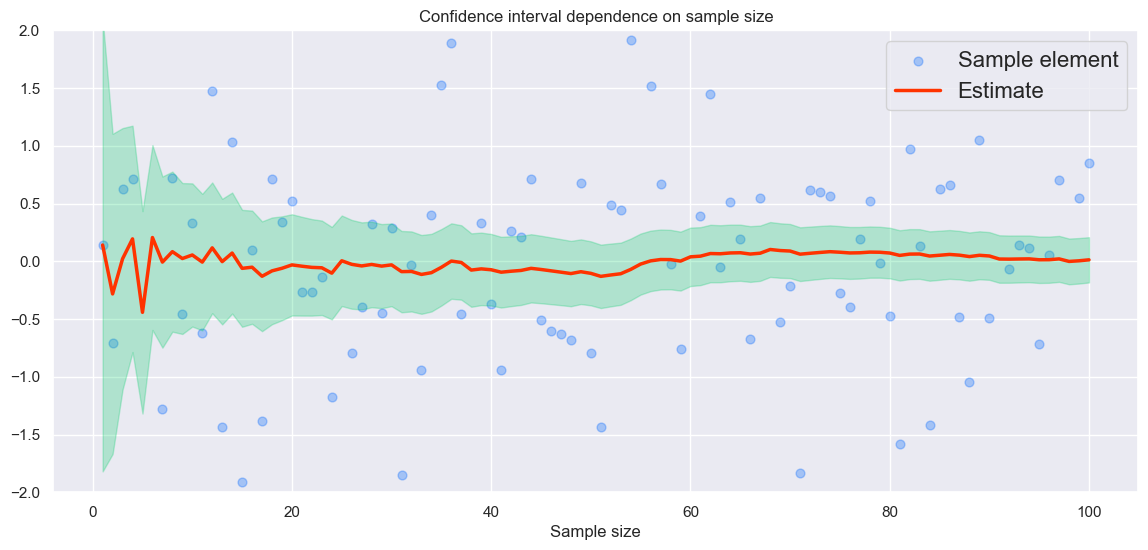

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps


def draw_confidence_interval(
    left,
    right,
    estimation=None,
    sample=None,
    ylim=(None, None),
    color_estimation='#FF3300',
    color_interval='#00CC66',
    color_sample='#0066FF',
    label_estimation='Estimate'
):
    """
    Plots the confidence interval and estimate depending on the sample size.

    :param left: left boundaries of the intervals (depending on n)
    :param right: right boundaries of the intervals (depending on n)
    :param estimation: estimates (depending on n)
    :param sample: sample data
    :param ylim: limits for the vertical axis
    :param color_estimation: color of the estimate
    :param color_interval: color of the interval
    :param color_sample: color of the sample
    :param label_estimation: label for the estimate plot
    """
    time = np.arange(len(left)) + 1

    assert len(time) == len(right)

    if sample is not None:
        plt.scatter(
            time, sample, alpha=0.3, color=color_sample,
            s=40, label='Sample element'
        )

    if estimation is not None:
        plt.plot(
            time, estimation, color=color_estimation,
            linewidth=2.5, label=label_estimation
        )

    plt.fill_between(time, left, right, alpha=0.25, color=color_interval)
    plt.legend(fontsize=16)

    if any(v is not None for v in ylim):
        plt.ylim(ylim)

    plt.xlabel('Sample size')
    plt.title('Confidence interval dependence on sample size')
    plt.grid(True)


# -----------------------------------------------------------------------------
# SAMPLE GENERATION AND PLOTTING
# -----------------------------------------------------------------------------

sample = sps.norm.rvs(size=100)  # generate sample
time = np.arange(len(sample)) + 1
alpha = 0.95

# compute estimate and boundaries
estimation = sample.cumsum() / time
left = estimation + sps.norm.ppf((1 - alpha) / 2) / np.sqrt(time)
right = estimation + sps.norm.ppf((1 + alpha) / 2) / np.sqrt(time)

plt.figure(figsize=(14, 6))
draw_confidence_interval(left, right, estimation, sample, ylim=(-2, 2))
plt.show()

## <u>Interval for 2 Samples</u>

$X_1, \ldots, X_n \sim \operatorname{Bern}(p_1)$ — drug treatment results  
$Y_1, \ldots, Y_m \sim \operatorname{Bern}(p_2)$ — placebo treatment results  

$p_1 = p_2$ — ?  

$$\hat{p}_1 = \bar{X}, \quad \hat{p}_2 = \bar{Y} \quad \Rightarrow \quad \hat{p}_1 - \hat{p}_2 = \bar{X} - \bar{Y} \text{ — effect estimate}$$

$$\hat{p}_1 = \bar{X} \overset{d}{\approx} \mathcal{N}\left(p_1, \frac{p_1(1-p_1)}{n}\right), \quad \hat{p}_2 = \bar{Y} \overset{d}{\approx} \mathcal{N}\left(p_2, \frac{p_2(1-p_2)}{m}\right)$$

$$\hat{p}_1 - \hat{p}_2 \overset{d}{\approx} \mathcal{N}\left(p_1 - p_2, \frac{p_1(1-p_1)}{n} + \frac{p_2(1-p_2)}{m}\right)$$

$$\hat{\sigma}^2 = \frac{\hat{p}_1(1-\hat{p}_1)}{n} + \frac{\hat{p}_2(1-\hat{p}_2)}{m}$$

$$\Rightarrow \text{interval for } p_1 - p_2: \quad C = \left(\hat{p}_1 - \hat{p}_2 - z_{\frac{1+\alpha}{2}}\hat{\sigma}, \quad \hat{p}_1 - \hat{p}_2 + z_{\frac{1+\alpha}{2}}\hat{\sigma}\right)$$

If $0 \in C$, then the result is insignificant.

## <u>Bootstrap</u>

Let $X_1, \ldots, X_n$ be a sample from a distribution $P$.  
$T(X)$ — some statistic, e.g., $T(X) = \frac{\overline{\sin X}}{\bar{X}}$.  
Goal: Estimate the variance of $T(X)$.  
If we had many realizations of $T(X)$, we would compute $S^2$ [Monte Carlo method].

<u>Bootstrap Sample</u>
* Generate indices $i_1, \ldots, i_n \sim \mathcal{U}\{1, \ldots, n\}$
* Obtain sample $X_1^* = (X_{i_1}, X_{i_2}, \ldots, X_{i_n})$ $\boxed{\text{of the same size}}$
* **Bootstrap Scheme:**

$$\begin{matrix}
X_{11}^*, \ldots, X_{1n}^* \to T_1^* \\
X_{21}^*, \ldots, X_{2n}^* \to T_2^* \\
\vdots \\
X_{B1}^*, \ldots, X_{Bn}^* \to T_B^*
\end{matrix} \Bigg\} \quad
\begin{aligned}
& v_{\text{boot}} \text{ — bootstrap variance estimator of } T(X) \\
& S^2 = \overline{T^{*2}} - (\bar{T}^*)^2 \\
& X = (2, 3, 5) \\
& X_1^* = (3, 3, 3) \\
& X_2^* = (2, 3, 5) \\
& \text{!} \quad B \text{ should be as large as possible}
\end{aligned}$$

<u>Application of the Delta Method for $T(X) = \frac{\overline{\sin X}}{\bar{X}}$</u>

Let $X_1, \ldots, X_n$ be an i.i.d. sample from distribution $P$.  
We aim to estimate the asymptotic variance of $T(X) = \frac{\overline{\sin X}}{\bar{X}}$.

**1. Multivariate Central Limit Theorem (CLT)**

Define the bivariate random vector $Y_i = (\sin X_i, X_i)^\top$. By the Multivariate CLT:

$$\sqrt{n} \left( \begin{pmatrix} \overline{\sin X} \\ \bar{X} \end{pmatrix} - \begin{pmatrix} \mu_1 \\ \mu_2 \end{pmatrix} \right) \xrightarrow{d} \mathcal{N}\left( 0, \Sigma \right)$$

where $\mu_1 = \mathbb{E}[\sin X_1]$, $\mu_2 = \mathbb{E}[X_1]$, and the covariance matrix is:

$$\Sigma = \begin{pmatrix} \operatorname{Var}(\sin X_1) & \operatorname{Cov}(\sin X_1, X_1) \\ \operatorname{Cov}(\sin X_1, X_1) & \operatorname{Var}(X_1) \end{pmatrix}$$

---

**2. Gradient Computation**

Let $g(u, v) = \frac{u}{v}$. Then $T(X) = g(\overline{\sin X}, \bar{X})$.  
The gradient matrix (vector) $D = \nabla g(u, v) \in \mathbb{R}^{1 \times 2}$ evaluated at $(\mu_1, \mu_2)$ is:

$$D = \left( \frac{\partial g}{\partial u}, \, \frac{\partial g}{\partial v} \right)\Bigg|_{(\mu_1, \mu_2)} = \left( \frac{1}{\mu_2}, \, -\frac{\mu_1}{\mu_2^2} \right)$$

---

**3. Asymptotic Variance via Delta Method**

By the Multivariate Delta Method:

$$\sqrt{n}\Big( T(X) - g(\mu_1, \mu_2) \Big) \xrightarrow{d} \mathcal{N}\left( 0, \, \sigma_{\text{asymp}}^2 \right)$$

where $\sigma_{\text{asymp}}^2 = D \Sigma D^\top$:

$$\sigma_{\text{asymp}}^2 = \begin{pmatrix} \frac{1}{\mu_2} & -\frac{\mu_1}{\mu_2^2} \end{pmatrix} \begin{pmatrix} \operatorname{Var}(\sin X_1) & \operatorname{Cov}(\sin X_1, X_1) \\ \operatorname{Cov}(\sin X_1, X_1) & \operatorname{Var}(X_1) \end{pmatrix} \begin{pmatrix} \frac{1}{\mu_2} \\ -\frac{\mu_1}{\mu_2^2} \end{pmatrix}$$

$$\sigma_{\text{asymp}}^2 = \frac{\operatorname{Var}(\sin X_1)}{\mu_2^2} - 2\frac{\mu_1}{\mu_2^3}\operatorname{Cov}(\sin X_1, X_1) + \frac{\mu_1^2}{\mu_2^4}\operatorname{Var}(X_1)$$

---

**4. Plug-in Variance Estimator**

Substituting sample estimators $\bar{X}, \overline{\sin X}, S^2_X, S^2_{\sin X}, \widehat{\operatorname{Cov}}(\sin X, X)$ for population moments yields:

$$v_{\text{delta}} = \widehat{\operatorname{Var}}(T(X)) = \frac{1}{n} \left[ \frac{S^2_{\sin X}}{\bar{X}^2} - 2\frac{\overline{\sin X}}{\bar{X}^3}\widehat{\operatorname{Cov}}(\sin X, X) + \frac{(\overline{\sin X})^2}{\bar{X}^4}S^2_X \right]$$

Observed T(X):          0.22153
Bootstrap Variance:     0.001744
Delta Method Variance:  0.001682


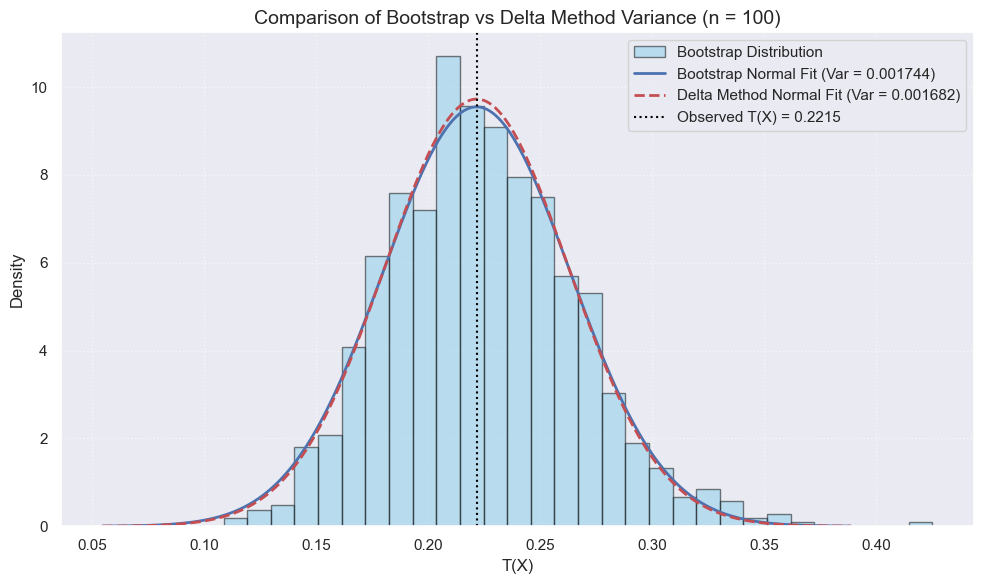

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------------------------------------------------------
# 1. SETUP AND SIMULATION PARAMETERS
# -----------------------------------------------------------------------------
np.random.seed(42)

# True distribution parameters (e.g., Exponential distribution)
scale_true = 2.0
n_samples = 100        # Sample size (n)
n_bootstraps = 1000    # Number of bootstrap iterations (B)

# Generate a single sample X
sample = np.random.exponential(scale=scale_true, size=n_samples)

# Statistic function T(X) = mean(sin(X)) / mean(X)
def compute_T(data):
    return np.mean(np.sin(data)) / np.mean(data)

T_observed = compute_T(sample)

# -----------------------------------------------------------------------------
# 2. METHOD 1: BOOTSTRAP
# -----------------------------------------------------------------------------
bootstrap_estimates = np.empty(n_bootstraps)

for i in range(n_bootstraps):
    boot_sample = np.random.choice(sample, size=n_samples, replace=True)
    bootstrap_estimates[i] = compute_T(boot_sample)

var_bootstrap = np.var(bootstrap_estimates, ddof=1)

# -----------------------------------------------------------------------------
# 3. METHOD 2: DELTA METHOD
# -----------------------------------------------------------------------------
mean_x = np.mean(sample)
mean_sin_x = np.mean(np.sin(sample))

var_x = np.var(sample, ddof=1)
var_sin_x = np.var(np.sin(sample), ddof=1)
cov_sin_x_x = np.cov(np.sin(sample), sample)[0, 1]

# Asymptotic variance formula via Delta Method
var_delta = (1 / n_samples) * (
    (var_sin_x / (mean_x**2))
    - (2 * mean_sin_x * cov_sin_x_x / (mean_x**3))
    + ((mean_sin_x**2) * var_x / (mean_x**4))
)

# -----------------------------------------------------------------------------
# 4. PRINT RESULTS & VISUALIZATION
# -----------------------------------------------------------------------------
print(f"Observed T(X):          {T_observed:.5f}")
print(f"Bootstrap Variance:     {var_bootstrap:.6f}")
print(f"Delta Method Variance:  {var_delta:.6f}")

# Plotting distributions
plt.figure(figsize=(10, 6))

# Histogram of bootstrap estimates
plt.hist(
    bootstrap_estimates, bins=30, density=True, alpha=0.5,
    color='skyblue', edgecolor='black', label='Bootstrap Distribution'
)

# Overlay normal approximations for both methods
x_grid = np.linspace(
    T_observed - 4 * np.sqrt(var_bootstrap),
    T_observed + 4 * np.sqrt(var_bootstrap),
    500
)

pdf_bootstrap = norm.pdf(x_grid, loc=T_observed, scale=np.sqrt(var_bootstrap))
pdf_delta = norm.pdf(x_grid, loc=T_observed, scale=np.sqrt(var_delta))

plt.plot(x_grid, pdf_bootstrap, 'b-', lw=2, label=f'Bootstrap Normal Fit (Var = {var_bootstrap:.6f})')
plt.plot(x_grid, pdf_delta, 'r--', lw=2, label=f'Delta Method Normal Fit (Var = {var_delta:.6f})')

plt.axvline(T_observed, color='black', linestyle=':', label=f'Observed T(X) = {T_observed:.4f}')

plt.title(f'Comparison of Bootstrap vs Delta Method Variance (n = {n_samples})', fontsize=14)
plt.xlabel('T(X)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Part 2

## **Hypotheses and Tests**

$X = (X_1, \ldots, X_n)$ — sample from an unknown distribution $P \in \mathscr{P}$.  
$H_0: P \in \mathscr{P}_0$ — null hypothesis;  
$H_1: P \in \mathscr{P}_1$ — alternative hypothesis.  

---

$S \subset \mathscr{X}$ — test of significance level $\alpha$ for testing $H_0 \text{ vs. } H_1$,  
if $\mathbb{P}(X \in S) \leqslant \alpha, \quad \forall P \in \mathscr{P}_0$.

---

**Possible decision outcomes:**

1. $X \in S \implies H_0 \text{ is rejected} \implies \text{result is statistically significant};$
2. $X \notin S \implies H_0 \text{ is \textbf{not rejected}} \implies \text{result is not statistically significant}$



Often the critical region has the form $S = \{T(X) \geqslant c\}$,  
where $T(X)$ is the test statistic.

$H_0 \text{ is rejected} \iff T(X) \geqslant c_\alpha$.  

For $S$, the value $t_1$ is **more extreme** than $t_2$ if $t_1 > t_2$.

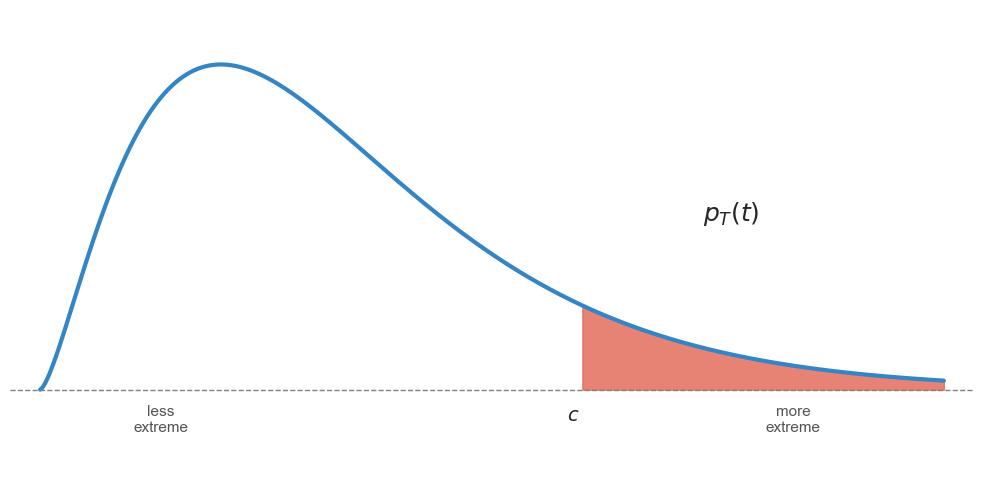

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Set up grid for a right-skewed distribution density curve p_T(t)
df = 5
x = np.linspace(0, 15, 500)
y = chi2.pdf(x, df)

c_alpha = 9.0  # Critical value c

fig, ax = plt.subplots(figsize=(10, 5))

# Plot PDF curve
ax.plot(x, y, color='#3385C6', lw=3)

# Fill critical region S = {T(X) >= c}
x_crit = np.linspace(c_alpha, 15, 200)
y_crit = chi2.pdf(x_crit, df)
ax.fill_between(x_crit, y_crit, color='#E26D5C', alpha=0.85)

# Dashed baseline
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Text labels
ax.text(11, 0.08, r'$p_T(t)$', fontsize=18, fontstyle='italic')
ax.text(c_alpha - 0.15, -0.015, r'$c$', fontsize=14, fontweight='bold', ha='center')
ax.text(2.0, -0.02, 'less\nextreme', fontsize=11, color='#555555', ha='center')
ax.text(12.5, -0.02, 'more\nextreme', fontsize=11, color='#555555', ha='center')

# Axis cleanup
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(-0.04, 0.18)
ax.axis('off')

plt.tight_layout()
plt.show()

<u>Tests</u>

**Def.**  
Let $\mathcal{X}$ be the sample space, $P \in \mathcal{P}$,  
$X = (X_1, \ldots, X_n)$ — sample from $P$.  

Then $S \subset \mathcal{X}$ is called a **test** (or critical region) for testing the hypothesis $H_0 \text{ vs } H_1$.

The rejection rule is formulated as follows: $H_0 \text{ is rejected} \iff X \in S$.

<u>Example</u>

$X_1 \sim \operatorname{Exp}(\theta)$. $H_0: \theta = \theta_0, \quad H_1: \theta > \theta_0$.  
Construct a test (significance level $\alpha$).

<u>Solution:</u> $\mathbb{E}X_1 = \frac{1}{\theta}$.  
As $\theta \uparrow, \, X_1 \downarrow \quad \Rightarrow \quad$ presumably, the critical region is $S = \{ x \in \mathcal{X} \mid x < c \}$.  

We choose $c$ from the constraint on the Type I error rate:
$$\mathbb{P}(I_S) = \mathbb{P}_{\theta_0}(X_1 < c) \leqslant \alpha$$

$$1 - e^{-\theta_0 c} \leqslant \alpha$$

$$1 - \alpha \leqslant e^{-\theta_0 c}$$

$$\ln(1 - \alpha) \leqslant -\theta_0 c$$

$$c \leqslant \frac{-\ln(1 - \alpha)}{\theta_0}$$

Thus, the critical region is: $S = \left\{ X_1 \; \middle| \; X_1 < \frac{-\ln(1 - \alpha)}{\theta_0} \right\}$

---

<u>Power function:</u> Let $\theta > \theta_0$.

$$\beta_S(\theta) = \mathbb{P}_\theta\left( X_1 < \frac{-\ln(1 - \alpha)}{\theta_0} \right) = 1 - e^{-\theta \left( \frac{-\ln(1 - \alpha)}{\theta_0} \right)} =$$

$$= 1 - \left( e^{\ln(1 - \alpha)} \right)^{\frac{\theta}{\theta_0}} = 1 - \underbrace{(1 - \alpha)}_{< 1}^{\frac{\theta}{\theta_0}} \xrightarrow[\theta \to \infty]{} 1$$

$$\beta_S(\theta_0) = 1 - (1 - \alpha)^{\frac{\theta_0}{\theta_0}} = \alpha$$

## <u>Wald Test</u>

We look for the limiting distribution of $T(X)$.

Let $X_1, \ldots, X_n$ be a sample from an unknown distribution  
$P \in \{ \mathbb{P}_\theta \mid \theta \in \Theta \}, \quad \theta \in \mathbb{R}$.

$H_0: \theta = \theta_0$  
$H_1: \theta \neq \theta_0$

Let $\hat{\theta}$ be an asymptotically normal estimator (A.N.E.) of $\theta$ with asymptotic variance $\sigma^2(\theta)$.

Then for $\theta = \theta_0$:

$$\frac{\sqrt{n}\left(\hat{\theta}(X) - \theta_0\right)}{\sigma(\theta_0)} \xrightarrow{d} \mathcal{N}(0, 1)$$

---

<u>Asymptotic test of significance level $\alpha$:</u>

$$\lim_{n \to \infty} \mathbb{P}(I_S) \leqslant \alpha$$

$$W(X) = \sqrt{n} \frac{\hat{\theta}(X) - \theta_0}{\hat{\sigma}(X)}$$

$$S = \{ |W(X)| > c \}$$

We choose $c$ from $\mathbb{P}(I_S) \leqslant \alpha$:

$$\Downarrow$$

$$S = \left\{ X \; \middle| \; |W(X)| > z_{1 - \frac{\alpha}{2}} \right\}$$

<u>Remark:</u>

This was a test for a two-sided alternative hypothesis.

1. $H_1: \theta > \theta_0 \implies S = \left\{ X \mid W(X) > z_{1-\alpha} \right\}$

2. $H_1: \theta < \theta_0 \implies S = \left\{ X \mid W(X) < -z_{1-\alpha} \right\}$

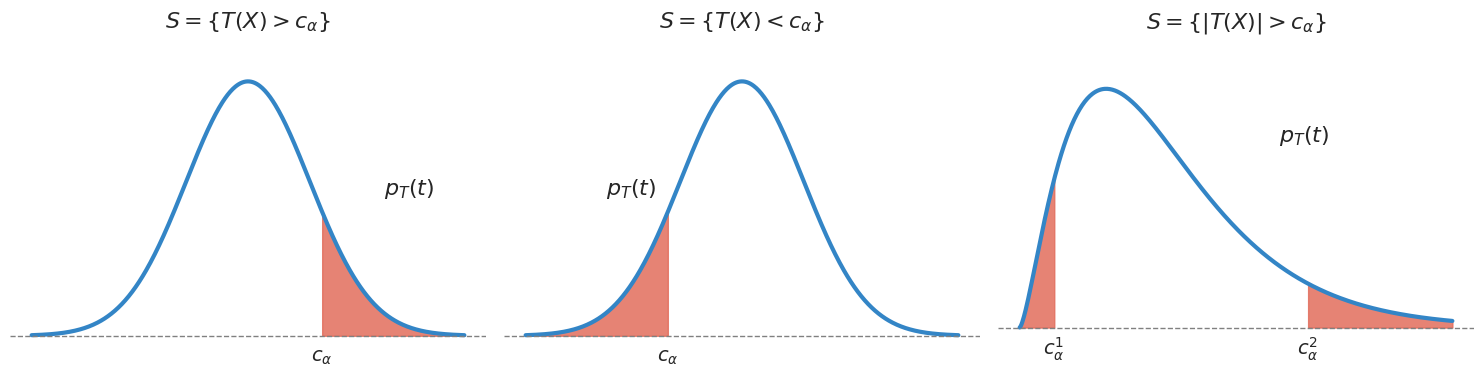

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2

# Set up the subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Common styling parameters
line_color = '#3385C6'
fill_color = '#E26D5C'
fill_alpha = 0.85

# -----------------------------------------------------------------------------
# 1. Right-tailed test: S = { T(X) > c_alpha }
# -----------------------------------------------------------------------------
x1 = np.linspace(-3.5, 3.5, 500)
y1 = norm.pdf(x1)
c1 = 1.2

axes[0].plot(x1, y1, color=line_color, lw=3)
x_crit1 = np.linspace(c1, 3.5, 200)
axes[0].fill_between(x_crit1, norm.pdf(x_crit1), color=fill_color, alpha=fill_alpha)

axes[0].set_title(r'$S = \{T(X) > c_\alpha\}$', fontsize=16, pad=15)
axes[0].text(2.2, 0.22, r'$p_T(t)$', fontsize=16, fontstyle='italic')
axes[0].text(c1, -0.04, r'$c_\alpha$', fontsize=14, ha='center')

# -----------------------------------------------------------------------------
# 2. Left-tailed test: S = { T(X) < c_alpha }
# -----------------------------------------------------------------------------
x2 = np.linspace(-3.5, 3.5, 500)
y2 = norm.pdf(x2)
c2 = -1.2

axes[1].plot(x2, y2, color=line_color, lw=3)
x_crit2 = np.linspace(-3.5, c2, 200)
axes[1].fill_between(x_crit2, norm.pdf(x_crit2), color=fill_color, alpha=fill_alpha)

axes[1].set_title(r'$S = \{T(X) < c_\alpha\}$', fontsize=16, pad=15)
axes[1].text(-2.2, 0.22, r'$p_T(t)$', fontsize=16, fontstyle='italic')
axes[1].text(c2, -0.04, r'$c_\alpha$', fontsize=14, ha='center')

# -----------------------------------------------------------------------------
# 3. Two-tailed / Asymmetric test: S = { |T(X)| > c_alpha }
# -----------------------------------------------------------------------------
df = 5
x3 = np.linspace(0, 15, 500)
y3 = chi2.pdf(x3, df)
c3_1, c3_2 = 1.2, 10.0

axes[2].plot(x3, y3, color=line_color, lw=3)

# Left tail fill
x_crit3_left = np.linspace(0, c3_1, 200)
axes[2].fill_between(x_crit3_left, chi2.pdf(x_crit3_left, df), color=fill_color, alpha=fill_alpha)

# Right tail fill
x_crit3_right = np.linspace(c3_2, 15, 200)
axes[2].fill_between(x_crit3_right, chi2.pdf(x_crit3_right, df), color=fill_color, alpha=fill_alpha)

axes[2].set_title(r'$S = \{|T(X)| > c_\alpha\}$', fontsize=16, pad=15)
axes[2].text(9.0, 0.12, r'$p_T(t)$', fontsize=16, fontstyle='italic')
axes[2].text(c3_1, -0.018, r'$c_\alpha^1$', fontsize=14, ha='center')
axes[2].text(c3_2, -0.018, r'$c_\alpha^2$', fontsize=14, ha='center')

# -----------------------------------------------------------------------------
# Formatting for all subplots
# -----------------------------------------------------------------------------
for ax in axes:
    ax.axhline(0, color='gray', linestyle='--', lw=1)
    ax.axis('off')

axes[0].set_ylim(-0.06, 0.45)
axes[1].set_ylim(-0.06, 0.45)
axes[2].set_ylim(-0.03, 0.18)

plt.tight_layout()
plt.show()

## **Example: A/B Test**

Users are randomly divided into two independent groups:

1. *Control group A* — sees the **old design**;  
   $X = (X_1, \ldots, X_n), \, X_i \sim \operatorname{Bern}(p_1)$ — outcomes.

2. *Treatment group B* — sees the **new design**;  
   $Y = (Y_1, \ldots, Y_m), \, Y_i \sim \operatorname{Bern}(p_2)$ — outcomes.

What can serve as an outcome?  
* Ad click.  
* User registration on the service.  
* Purchase of a service.  
* etc.  

---

**Hypotheses:**

* $H_0: p_1 = p_2$ — no effect
* $H_1: p_1 < p_2$ — effect is present



From the CLT we can obtain:

$$\hat{p}_1 = \overline{X} \xrightarrow{d} \mathcal{N}\left(p_1, \frac{p_1(1 - p_1)}{n}\right), \quad \hat{p}_2 = \overline{Y} \xrightarrow{d} \mathcal{N}\left(p_2, \frac{p_2(1 - p_2)}{m}\right)$$

Under $H_0$, we obtain:

$$W(X, Y) = \frac{\hat{p}_2 - \hat{p}_1}{\hat{\sigma}} \xrightarrow{d} \mathcal{N}(0, 1)$$

where $\hat{\sigma} = \sqrt{\frac{\hat{p}_1(1 - \hat{p}_1)}{n} + \frac{\hat{p}_2(1 - \hat{p}_2)}{m}}$.

The convergence $W(X, Y) \xrightarrow{d} \mathcal{N}(0, 1)$ as $n, m \to +\infty$ can be proven rigorously.

---

**Wald test** $S = \{ W(x, y) > z_{1 - \alpha} \}$.

$$\alpha = 0.05 \implies z_{1 - \alpha} \approx 1.64, \quad S = \{ W(x, y) > 1.64 \}$$

Confidence interval for $p_2 - p_1$ is $C = (\hat{p}_2 - \hat{p}_1 - z_{1 - \alpha}\hat{\sigma}, 1)$.

$$H_0 \text{ is rejected} \iff 0 \notin C$$



1. Group 1: $n = 30$ people, 21 converted $\implies \hat{p}_1 = 0.7$  
   Group 2: $m = 30$ people, 27 converted $\implies \hat{p}_2 = 0.9$  
   $W(x, y) \approx 2 \implies H_0 \text{ is rejected, result is stat. significant}$  
   confidence interval $(0.036, 1)$

2. Group 1: $n = 30$ people, 15 converted $\implies \hat{p}_1 = 0.5$  
   Group 2: $m = 30$ people, 27 converted $\implies \hat{p}_2 = 0.9$  
   $W(x, y) \approx 3.76 \implies H_0 \text{ is rejected, result is stat. significant}$  
   confidence interval $(0.225, 1)$

3. Group 1: $n = 10$ people, 7 converted $\implies \hat{p}_1 = 0.7$  
   Group 2: $m = 30$ people, 27 converted $\implies \hat{p}_2 = 0.9$  
   $W(x, y) \approx 1.29 \implies H_0 \text{ is not rejected, result is stat. insignificant}$  
   confidence interval $(-0.055, 1)$

## **p-value** (attained significance level)

$H_0: P \in \mathcal{P}_0$  
$x_1, \ldots, x_n$ — realization of the sample  
$T(X)$ — test statistic  
$t = T(x_1, \ldots, x_n)$ — realization of the test statistic  

**p-value** — probability of obtaining a test statistic value $t = T(x)$ or a value even more extreme, assuming $H_0$ is true.

---

| Right-tailed | Left-tailed | Two-tailed |
| :---: | :---: | :---: |
| $S = \{ T(x) > c_\alpha \}$ | $S = \{ T(x) < c_\alpha \}$ | $S = \{ \|T(x)\| > c_\alpha \}$ |
| $p(x) = \mathbb{P}_0(T(X) \geqslant t)$ | $p(x) = \mathbb{P}_0(T(X) \leqslant t)$ | $p(x) = \mathbb{P}_0(T(X) \geqslant \|t\|) + \mathbb{P}_0(T(X) \leqslant -\|t\|)$ |

---

*Remark.* If the distribution of $T(X)$ under $H_0$ is not unique (composite hypothesis), one needs to take $\sup_{P \in \mathcal{P}_0}$.  
*Remark.* For asymptotic tests, the limiting distribution is used.

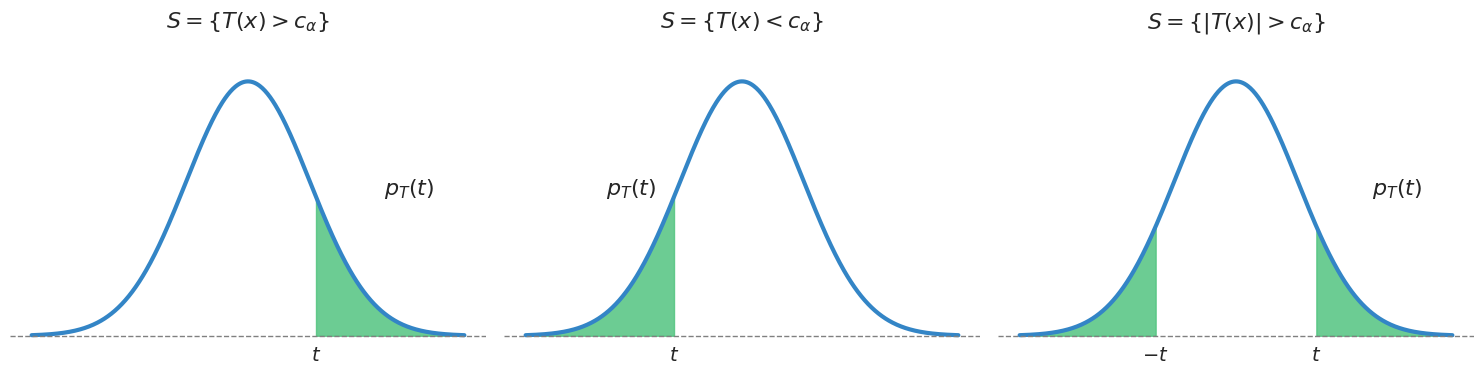

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Setup subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Styling constants
line_color = '#3385C6'
fill_color = '#52C480'  # Green shade from the slide
fill_alpha = 0.85

x = np.linspace(-3.5, 3.5, 500)
y = norm.pdf(x)

# -----------------------------------------------------------------------------
# 1. Right-tailed: p(x) = P0(T(X) >= t)
# -----------------------------------------------------------------------------
t1 = 1.1
axes[0].plot(x, y, color=line_color, lw=3)
x_tail1 = np.linspace(t1, 3.5, 200)
axes[0].fill_between(x_tail1, norm.pdf(x_tail1), color=fill_color, alpha=fill_alpha)

axes[0].set_title(r'$S = \{T(x) > c_\alpha\}$', fontsize=16, pad=15)
axes[0].text(2.2, 0.22, r'$p_T(t)$', fontsize=16, fontstyle='italic')
axes[0].text(t1, -0.04, r'$t$', fontsize=14, ha='center')

# -----------------------------------------------------------------------------
# 2. Left-tailed: p(x) = P0(T(X) <= t)
# -----------------------------------------------------------------------------
t2 = -1.1
axes[1].plot(x, y, color=line_color, lw=3)
x_tail2 = np.linspace(-3.5, t2, 200)
axes[1].fill_between(x_tail2, norm.pdf(x_tail2), color=fill_color, alpha=fill_alpha)

axes[1].set_title(r'$S = \{T(x) < c_\alpha\}$', fontsize=16, pad=15)
axes[1].text(-2.2, 0.22, r'$p_T(t)$', fontsize=16, fontstyle='italic')
axes[1].text(t2, -0.04, r'$t$', fontsize=14, ha='center')

# -----------------------------------------------------------------------------
# 3. Two-tailed: p(x) = P0(T(X) >= |t|) + P0(T(X) <= -|t|)
# -----------------------------------------------------------------------------
t3 = 1.3
axes[2].plot(x, y, color=line_color, lw=3)

# Left tail (-t)
x_tail3_left = np.linspace(-3.5, -t3, 200)
axes[2].fill_between(x_tail3_left, norm.pdf(x_tail3_left), color=fill_color, alpha=fill_alpha)

# Right tail (t)
x_tail3_right = np.linspace(t3, 3.5, 200)
axes[2].fill_between(x_tail3_right, norm.pdf(x_tail3_right), color=fill_color, alpha=fill_alpha)

axes[2].set_title(r'$S = \{|T(x)| > c_\alpha\}$', fontsize=16, pad=15)
axes[2].text(2.2, 0.22, r'$p_T(t)$', fontsize=16, fontstyle='italic')
axes[2].text(-t3, -0.04, r'$-t$', fontsize=14, ha='center')
axes[2].text(t3, -0.04, r'$t$', fontsize=14, ha='center')

# Format axes
for ax in axes:
    ax.axhline(0, color='gray', linestyle='--', lw=1)
    ax.axis('off')
    ax.set_ylim(-0.06, 0.45)

plt.tight_layout()
plt.show()

## **Property of p-value**

**Proposition.**

If, under $H_0$, the distribution of the test statistic $T(X)$ is identical and continuous, then $p(T(X)) \sim U[0, 1]$ under $H_0$.

---

*Proof.*  
Consider a left-tailed test with critical region $S = \{ T(x) < c_\alpha \}$.  
The cumulative distribution function (CDF) of $T(X)$ under $H_0$ is defined as:

$$F_T(t) = \mathbb{P}_0(T(X) \leqslant t)$$

By definition of the $p$-value for a left-tailed test:

$$p(t) = \sup_{P \in \mathcal{P}_0} \mathbb{P}(T(X) \leqslant t) = \mathbb{P}_0(T(X) \leqslant t) = F_T(t)$$

Since the distribution of $T(X)$ is continuous, applying the Probability Integral Transform yields:

$$p(T(X)) = F_T(T(X)) \sim U[0, 1]$$

*(Note: For a right-tailed test, $p(T(X)) = 1 - F_T(T(X)) \sim U[0, 1]$ similarly).*


**Proposition.**

If, assuming $H_0$ is true,  
the distribution of the statistic $T(X)$ is identical and continuous,  
then $p(T(X)) \sim U[0, 1]$ under $H_0$.

---

*Remark.*  
This is often true in practice, as many statistical tests are constructed this way.

Before applying a test in practice, it is worth checking its correctness using multiple sampling under the assumption that $H_0$ is true. In particular, the $p$-value usually behaves like this:

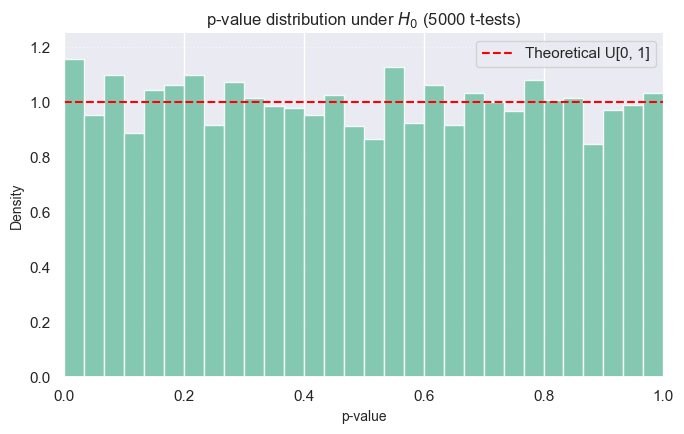

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters
n_simulations = 5000  # Number of test runs
sample_size = 100      # Sample size for each run
mu_0 = 0              # True mean (H0 is true)

p_values = []

# Simulate experiments
for _ in range(n_simulations):
    # Generate sample from N(0, 1)
    sample = np.random.normal(loc=mu_0, scale=1.0, size=sample_size)

    # Perform a 1-sample t-test (H0: mu = 0)
    _, p_val = stats.ttest_1samp(sample, popmean=mu_0)
    p_values.append(p_val)

# Plotting the histogram
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    p_values,
    bins=30,
    density=True,
    color='#72C3A6',  # Mint-green shade matching the slide
    edgecolor='white',
    alpha=0.85
)

# Theoretical density line for U[0, 1]
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Theoretical U[0, 1]')

# Formatting and layout
ax.set_title('p-value distribution under $H_0$ (5000 t-tests)', fontsize=12)
ax.set_xlabel('p-value', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.25)
ax.legend(frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

*Corollary.*

Values of 0.2 and 0.9 are equivalent from the perspective of $H_0$ being true,  
i.e., the $p$-value is not a degree of confidence in the validity of $H_0$.

---

What is possible if the $p$-value is large?

1. $H_0$ is true;
2. The test is not powerful enough.

## **General case of p-value**

$\{S_\alpha \mid \alpha \in [0, 1]\}$ — family of tests for different significance levels.

$S_\alpha = \{ T(x) > c_\alpha \}$ — test

**Conclusion:**

The $p$-value is the smallest significance level at which $H_0$ can be rejected for a given sample realization $x$.

$$p(x) = \inf\{\alpha \in [0, 1] \mid x \in S_\alpha\}$$